# DBSCAN hyperedges on TopTagging jets

Density-based patch finding in **$\Delta R$** space $(\eta,\phi)$ as a candidate
hyperedge construction (vs star-$R$).

**Template**

1. Run DBSCAN on pairwise $\Delta R$ (precomputed), optionally after a small
   $p_T$ inclusion cut (`min_pt`) so soft radiation can still seed patches.
2. Sweep `eps` × `min_samples` (and a few small `min_pt`) → mean **#clusters =
   #hyperedges** for **top** vs **QCD** separately.
3. At a few promising `(eps, min_samples[, min_pt])`, plot **noise fraction**
   among particles with $p_T > T$ (and the complementary clustered fraction).
   Rising clustered fraction with $T$ means soft particles are noise — we do
   **not** count the noise label as a cluster. Also report jet $p_T$ captured
   by clusters.
4. Visualize patches: fixed-size markers, color = cluster id; gray = noise.
5. Histogram **DBSCAN-cluster invariant mass** (4-sum of members) for top vs QCD
   at the training defaults (`eps=0.08`, `min_samples=2`). A hadronic $W$ in
   boosted tops should show up near $m \sim 80$ GeV.

Noise (label $-1$) is **not** a hyperedge.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

REPO = Path("..").resolve()
sys.path[:0] = [str(REPO), str(REPO / "src")]

from cpen.utils.graph_radius import (
    delta_r,
    eta_phi_from_four_vectors,
    particle_mask_from_four_vectors,
)
from cpen.utils.toptagging import (
    MAX_NUM_PARTICLES,
    N_PARTICLE_FEATURES,
    raw_hdf5_path,
)

import scienceplots  # noqa: F401

plt.style.use(["science", "no-latex"])
mpl.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

FIG_DIR = Path("figures/dbscan_jet_study")
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging")
SPLIT = "train"
NUM_PARTICLES = 128
N_JETS_PER_CLASS = 200  # sweep statistics
N_VIZ = 5               # jets to draw per class
SEED = 0

# Particle pT cut before DBSCAN (GeV). Keep small so soft radiation can patch.
MIN_PT_GRID = np.array([0.0, 0.5, 1.0])
EPS_GRID = np.linspace(0.025, 0.25, 20)
MIN_SAMPLES_GRID = np.array([1, 2, 3, 4, 5])

# Coverage + viz defaults (override after looking at the sweep).
PROMISING = [
    dict(eps=0.05, min_samples=1, min_pt=0.01),
    dict(eps=0.1, min_samples=1, min_pt=0.01),
    dict(eps=0.05, min_samples=2, min_pt=0.01),
    dict(eps=0.1, min_samples=2, min_pt=0.01),
]
PT_THRESH_GRID = np.geomspace(0.01, 2.51, 20)

print(f"figs → {FIG_DIR.resolve()}")

figs → /home/jdezoort/coupled-particle-edge-networks/notebooks/figures/dbscan_jet_study


## Load jets

Raw HDF5 layout `[E, px, py, pz]` per particle (same as star-$R$ notebooks).

In [2]:
def jet_kinematics(jet: np.ndarray) -> dict[str, np.ndarray]:
    """Active-particle kinematics for one jet `(Npad, 4)`."""
    mask = particle_mask_from_four_vectors(jet)
    active = np.flatnonzero(mask)
    x = jet[active]
    eta, phi = eta_phi_from_four_vectors(x)
    px, py = x[:, 1], x[:, 2]
    pt = np.hypot(px, py)
    energy = x[:, 0]
    return dict(active=active, eta=eta, phi=phi, pt=pt, energy=energy, x=x)


def pairwise_delta_r(eta: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """Dense ΔR distance matrix `(n, n)`."""
    n = len(eta)
    d = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        d[i] = delta_r(eta[i], phi[i], eta, phi)
    return d


def dbscan_delta_r(
    kin: dict[str, np.ndarray],
    *,
    eps: float,
    min_samples: int,
    min_pt: float = 0.0,
) -> dict[str, np.ndarray | int | float]:
    """DBSCAN on particles with ``pt >= min_pt``; others forced to noise (-1).

    Returns labels aligned to **all active** particles in ``kin``.
    """
    pt = kin["pt"]
    n = len(pt)
    labels = np.full(n, -1, dtype=np.int64)
    keep = pt >= float(min_pt)
    if keep.sum() < int(min_samples):
        return dict(
            labels=labels,
            n_clusters=0,
            n_clustered=0,
            n_active=n,
            n_eligible=int(keep.sum()),
            frac_clustered=0.0,
        )
    idx = np.flatnonzero(keep)
    d = pairwise_delta_r(kin["eta"][idx], kin["phi"][idx])
    lab = DBSCAN(eps=float(eps), min_samples=int(min_samples), metric="precomputed").fit_predict(d)
    labels[idx] = lab
    clustered = labels >= 0
    n_clusters = int(labels.max() + 1) if clustered.any() else 0
    return dict(
        labels=labels,
        n_clusters=n_clusters,
        n_clustered=int(clustered.sum()),
        n_active=n,
        n_eligible=int(keep.sum()),
        frac_clustered=float(clustered.sum() / max(n, 1)),
    )


hdf5_path = raw_hdf5_path(DATA_ROOT, SPLIT)
assert hdf5_path.is_file(), hdf5_path
table = pd.read_hdf(hdf5_path, key="table")
total_pf = MAX_NUM_PARTICLES * N_PARTICLE_FEATURES
labels_all = table.iloc[:, -1].to_numpy(dtype=np.int64)

rng = np.random.default_rng(SEED)
jets: dict[str, list[np.ndarray]] = {"top": [], "QCD": []}
jet_ids: dict[str, list[int]] = {"top": [], "QCD": []}
for class_label, name in [(1, "top"), (0, "QCD")]:
    pool = np.flatnonzero(labels_all == class_label)
    chosen = rng.choice(pool, size=N_JETS_PER_CLASS, replace=False)
    for idx in chosen:
        row = table.iloc[int(idx), :total_pf].to_numpy(dtype=np.float32)
        jet = row.reshape(MAX_NUM_PARTICLES, N_PARTICLE_FEATURES)[:NUM_PARTICLES]
        jets[name].append(jet)
        jet_ids[name].append(int(idx))

kins: dict[str, list[dict]] = {
    name: [jet_kinematics(j) for j in js] for name, js in jets.items()
}
for name in jets:
    ns = [len(k["pt"]) for k in kins[name]]
    print(
        f"{name}: n_jets={len(jets[name])}  "
        f"N_active median={np.median(ns):.0f}  "
        f"[{np.min(ns)}, {np.max(ns)}]"
    )

top: n_jets=200  N_active median=54  [28, 119]
QCD: n_jets=200  N_active median=38  [10, 104]


## Sweep: #hyperedges vs `eps`

Each DBSCAN cluster → one hyperedge. Curves = mean over jets ± SEM.
Panels: `min_pt` (rows) × class (columns). Line color = `min_samples`.

,class_name,min_pt,min_samples,eps,n_hyperedges_mean,n_hyperedges_sem,n_hyperedges_median
0,top,0.0,1,0.025000,43.530,0.857451,43.0
1,top,0.0,1,0.036842,38.560,0.761829,38.0
2,top,0.0,1,0.048684,33.845,0.674075,33.0
3,top,0.0,1,0.060526,29.305,0.589105,28.0
4,top,0.0,1,0.072368,25.310,0.505020,24.5


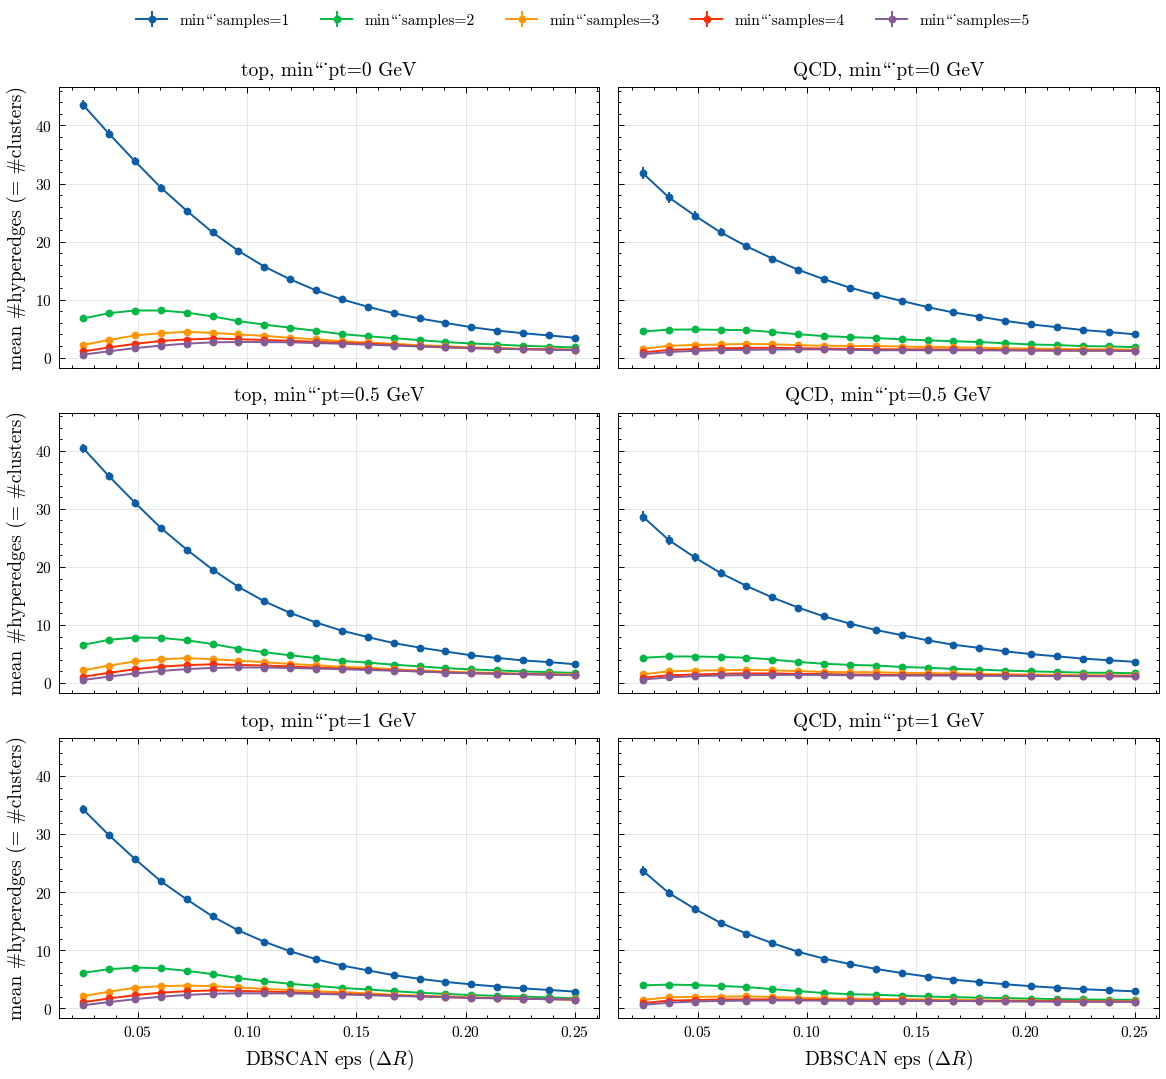

In [3]:
rows = []
for name, kin_list in kins.items():
    for min_pt in MIN_PT_GRID:
        for min_samples in MIN_SAMPLES_GRID:
            for eps in EPS_GRID:
                n_cl = []
                for kin in kin_list:
                    out = dbscan_delta_r(
                        kin, eps=eps, min_samples=int(min_samples), min_pt=float(min_pt)
                    )
                    n_cl.append(out["n_clusters"])
                n_cl = np.asarray(n_cl, dtype=np.float64)
                rows.append(
                    dict(
                        class_name=name,
                        min_pt=float(min_pt),
                        min_samples=int(min_samples),
                        eps=float(eps),
                        n_hyperedges_mean=float(n_cl.mean()),
                        n_hyperedges_sem=float(n_cl.std(ddof=1) / np.sqrt(len(n_cl))),
                        n_hyperedges_median=float(np.median(n_cl)),
                    )
                )

sweep = pd.DataFrame(rows)
display(sweep.head())

fig, axes = plt.subplots(
    len(MIN_PT_GRID), 2, figsize=(8.5, 2.6 * len(MIN_PT_GRID)), sharex=True, sharey=True
)
if len(MIN_PT_GRID) == 1:
    axes = np.asarray([axes])

for i, min_pt in enumerate(MIN_PT_GRID):
    for j, name in enumerate(["top", "QCD"]):
        ax = axes[i, j]
        sub = sweep[(sweep["class_name"] == name) & (np.isclose(sweep["min_pt"], min_pt))]
        for min_samples in MIN_SAMPLES_GRID:
            s = sub[sub["min_samples"] == int(min_samples)].sort_values("eps")
            ax.errorbar(
                s["eps"],
                s["n_hyperedges_mean"],
                yerr=s["n_hyperedges_sem"],
                marker="o",
                ms=3,
                lw=1.0,
                label=rf"min\_samples={int(min_samples)}",
            )
        ax.set_title(rf"{name}, min\_pt={min_pt:g} GeV")
        if i == len(MIN_PT_GRID) - 1:
            ax.set_xlabel(r"DBSCAN eps ($\Delta R$)")
        if j == 0:
            ax.set_ylabel(r"mean #hyperedges (= #clusters)")
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(MIN_SAMPLES_GRID), frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "n_hyperedges_vs_eps.pdf", bbox_inches="tight")
plt.show()

## Hard-particle capture vs $p_T$ threshold

**Not counting noise as a cluster.** Labels $<0$ are noise (or below `min_pt`);
only labels $\ge 0$ count as clustered.

For fixed `(eps, min_samples, min_pt)`, among particles with $p_T > T$:

- **clustered fraction** — often *rises* with $T$. Soft junk is preferentially
  noise, so raising $T$ removes those points and the remaining hard core looks
  more clustered. That is expected, not a bug.
- **noise fraction** $= 1 - \mathrm{clustered}$ — usually *falls* with $T$
  (clearer “are we missing hard prongs?” view).
- **jet $p_T$ in clusters** — $\sum p_T(\mathrm{clustered})/\sum p_T(\mathrm{jet})$,
  a single operating-point summary (horizontal reference per config).

If clustered-fraction-vs-$T$ still feels unhelpful, lean on the noise-fraction
and jet-$p_T$ panels.

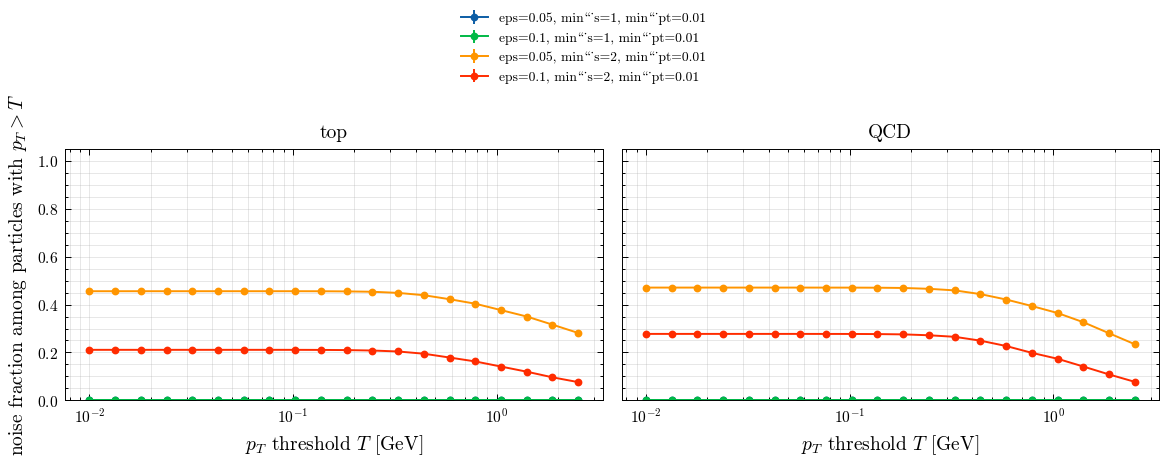

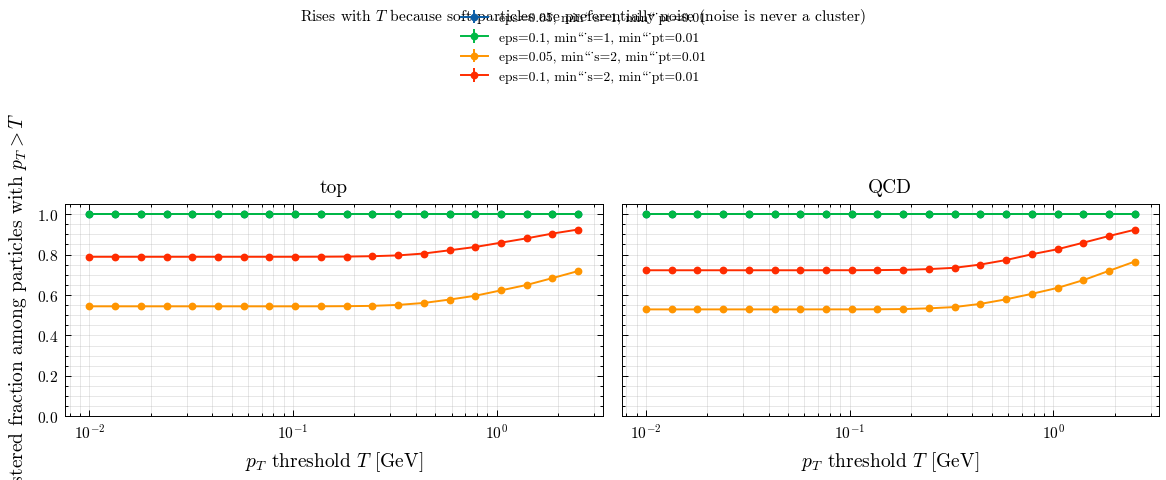

Mean jet pT fraction inside DBSCAN clusters (noise excluded):


,class_name,eps,min_samples,min_pt,jet_pt_in_clusters,jet_pt_sem
0,top,0.05,1,0.01,1.000,0.000
1,top,0.10,1,0.01,1.000,0.000
2,top,0.05,2,0.01,0.824,0.008
3,top,0.10,2,0.01,0.955,0.003
4,QCD,0.05,1,0.01,1.000,0.000
5,QCD,0.10,1,0.01,1.000,0.000
6,QCD,0.05,2,0.01,0.872,0.008
7,QCD,0.10,2,0.01,0.961,0.004


Edit PROMISING after inspecting the sweep if these defaults look wrong.


In [4]:
def hard_particle_stats(
    kin_list: list[dict],
    *,
    eps: float,
    min_samples: int,
    min_pt: float,
    pt_grid: np.ndarray = PT_THRESH_GRID,
) -> tuple[pd.DataFrame, float, float]:
    """Per-threshold hard-particle clustered/noise fractions + jet pT capture."""
    labeled = [
        (
            kin,
            dbscan_delta_r(kin, eps=eps, min_samples=min_samples, min_pt=min_pt)["labels"],
        )
        for kin in kin_list
    ]
    # Jet-level pT fraction in clusters (labels >= 0 only; noise excluded).
    pt_fracs = []
    for kin, lab in labeled:
        pt = kin["pt"]
        denom = float(pt.sum())
        if denom <= 0:
            continue
        pt_fracs.append(float(pt[lab >= 0].sum() / denom))
    pt_fracs = np.asarray(pt_fracs, dtype=np.float64)
    jet_pt_in_clusters = float(pt_fracs.mean()) if len(pt_fracs) else float("nan")
    jet_pt_sem = (
        float(pt_fracs.std(ddof=1) / np.sqrt(len(pt_fracs))) if len(pt_fracs) > 1 else float("nan")
    )

    rows = []
    for T in pt_grid:
        clustered_fracs = []
        for kin, lab in labeled:
            hard = kin["pt"] > float(T)
            if not hard.any():
                continue
            # Noise is label -1 — never counted as clustered.
            clustered_fracs.append(float((lab[hard] >= 0).mean()))
        clustered_fracs = np.asarray(clustered_fracs, dtype=np.float64)
        if len(clustered_fracs) == 0:
            rows.append(
                dict(
                    pt_thresh=float(T),
                    clustered_mean=np.nan,
                    clustered_sem=np.nan,
                    noise_mean=np.nan,
                    noise_sem=np.nan,
                    n_jets=0,
                )
            )
            continue
        c_mean = float(clustered_fracs.mean())
        c_sem = (
            float(clustered_fracs.std(ddof=1) / np.sqrt(len(clustered_fracs)))
            if len(clustered_fracs) > 1
            else float("nan")
        )
        rows.append(
            dict(
                pt_thresh=float(T),
                clustered_mean=c_mean,
                clustered_sem=c_sem,
                noise_mean=1.0 - c_mean,
                noise_sem=c_sem,
                n_jets=int(len(clustered_fracs)),
            )
        )
    return pd.DataFrame(rows), jet_pt_in_clusters, jet_pt_sem


fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4), sharey=True)
jet_pt_summary = []
for ax, name in zip(axes, ["top", "QCD"]):
    for cfg in PROMISING:
        curve, jet_pt, jet_pt_sem = hard_particle_stats(kins[name], **cfg)
        jet_pt_summary.append(dict(class_name=name, **cfg, jet_pt_in_clusters=jet_pt, jet_pt_sem=jet_pt_sem))
        label = (
            rf"eps={cfg['eps']:g}, min\_s={cfg['min_samples']}, "
            rf"min\_pt={cfg['min_pt']:g}"
        )
        # Noise fraction among (pT > T): falls with T if soft particles are the noise.
        ax.errorbar(
            curve["pt_thresh"],
            curve["noise_mean"],
            yerr=curve["noise_sem"],
            marker="o",
            ms=3,
            lw=1.0,
            label=label,
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"$p_T$ threshold $T$ [GeV]")
    ax.set_title(name)
    ax.grid(True, alpha=0.3, which="both")
axes[0].set_ylabel(r"noise fraction among particles with $p_T>T$")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, fontsize=7)
fig.tight_layout(rect=[0, 0, 1, 0.78])
fig.savefig(FIG_DIR / "noise_frac_vs_pt_thresh.pdf", bbox_inches="tight")
plt.show()

# Same selection as clustered fraction (rises with T) — kept for comparison.
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4), sharey=True)
for ax, name in zip(axes, ["top", "QCD"]):
    for cfg in PROMISING:
        curve, _, _ = hard_particle_stats(kins[name], **cfg)
        ax.errorbar(
            curve["pt_thresh"],
            curve["clustered_mean"],
            yerr=curve["clustered_sem"],
            marker="o",
            ms=3,
            lw=1.0,
            label=(
                rf"eps={cfg['eps']:g}, min\_s={cfg['min_samples']}, "
                rf"min\_pt={cfg['min_pt']:g}"
            ),
        )
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"$p_T$ threshold $T$ [GeV]")
    ax.set_title(name)
    ax.grid(True, alpha=0.3, which="both")
axes[0].set_ylabel(r"clustered fraction among particles with $p_T>T$")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, fontsize=7)
fig.suptitle(
    r"Rises with $T$ because soft particles are preferentially noise (noise is never a cluster)",
    fontsize=8,
    y=1.02,
)
fig.tight_layout(rect=[0, 0, 1, 0.78])
fig.savefig(FIG_DIR / "clustered_frac_vs_pt_thresh.pdf", bbox_inches="tight")
plt.show()

pt_df = pd.DataFrame(jet_pt_summary)
print("Mean jet pT fraction inside DBSCAN clusters (noise excluded):")
display(
    pt_df[
        ["class_name", "eps", "min_samples", "min_pt", "jet_pt_in_clusters", "jet_pt_sem"]
    ].round(3)
)
print("Edit PROMISING after inspecting the sweep if these defaults look wrong.")


## Visualize hyperedges in $(\eta,\phi)$

**Fixed marker size** (not $p_T$-scaled) so cluster extent is easy to see.
Color = cluster id; **light gray = DBSCAN noise** (label $-1$), including
particles dropped by `min_pt` before clustering.
Uses the first entry of `PROMISING` unless you change `VIZ_CFG`.

Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], 

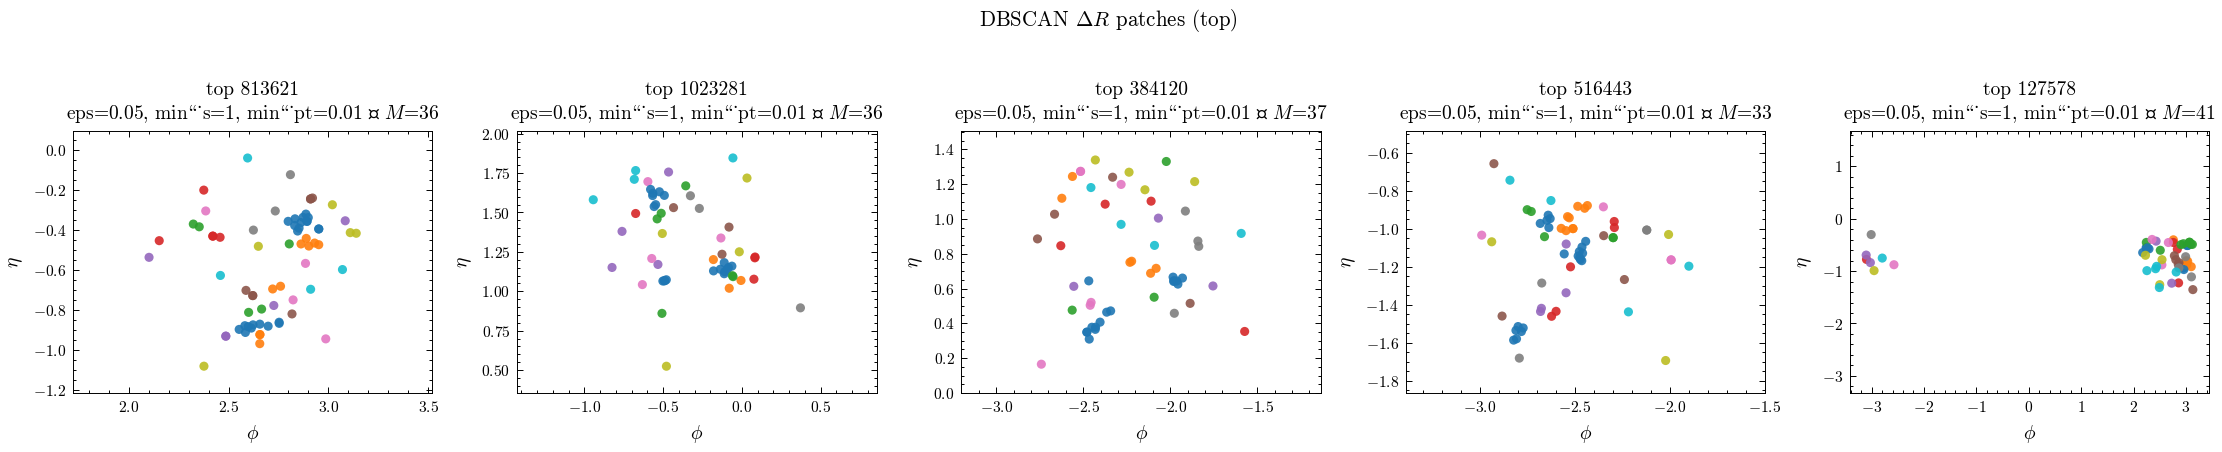

Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2192' [U+2192], 

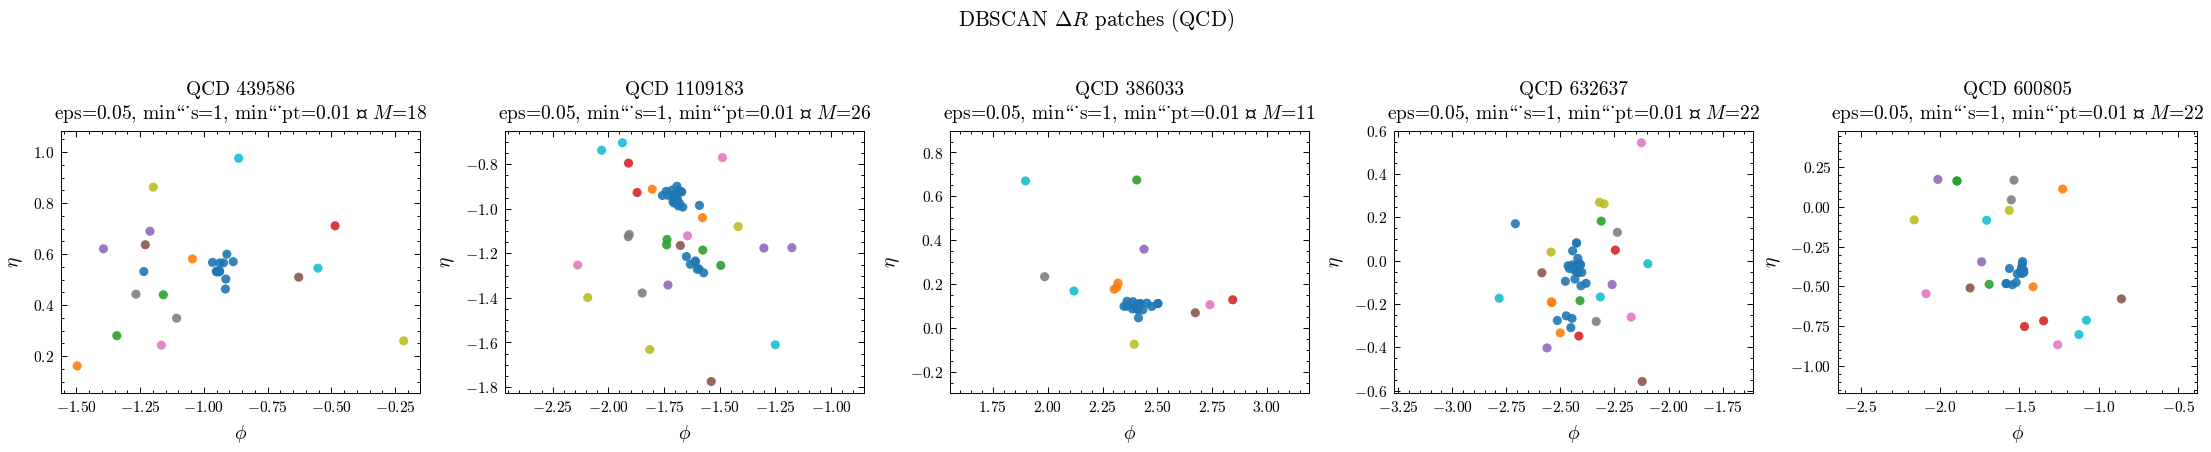

In [5]:
VIZ_CFG = dict(PROMISING[0])


def plot_dbscan_jet(
    kin: dict[str, np.ndarray],
    *,
    eps: float,
    min_samples: int,
    min_pt: float,
    ax=None,
    title: str | None = None,
):
    out = dbscan_delta_r(kin, eps=eps, min_samples=min_samples, min_pt=min_pt)
    labels = out["labels"]
    eta, phi, pt = kin["eta"], kin["phi"], kin["pt"]
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.4))

    # Fixed size so cluster spatial extent is visible (not pT-weighted).
    sizes = np.full(len(pt), 22.0)
    noise = labels < 0
    ax.scatter(
        phi[noise],
        eta[noise],
        s=sizes[noise],
        c="0.75",
        alpha=0.55,
        linewidths=0,
        rasterized=True,
        label="noise (DBSCAN -1 / below min_pt)",
    )
    clustered = ~noise
    if clustered.any():
        sc = ax.scatter(
            phi[clustered],
            eta[clustered],
            s=sizes[clustered],
            c=labels[clustered],
            cmap="tab10",
            alpha=0.9,
            linewidths=0,
            rasterized=True,
        )
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"$\eta$")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(
        title
        or (
            rf"eps={eps:g}, min\_s={min_samples}, min\_pt={min_pt:g}"
            + rf"  →  $M$={out['n_clusters']}"
        )
    )
    return out, ax


for name in ["top", "QCD"]:
    fig, axes = plt.subplots(1, N_VIZ, figsize=(3.2 * N_VIZ, 3.2), sharex=False, sharey=False)
    if N_VIZ == 1:
        axes = [axes]
    for ax, kin, jid in zip(axes, kins[name][:N_VIZ], jet_ids[name][:N_VIZ]):
        out, _ = plot_dbscan_jet(kin, ax=ax, title=None, **VIZ_CFG)
        ax.set_title(
            rf"{name} {jid}"
            + "\n"
            + rf"eps={VIZ_CFG['eps']:g}, min\_s={VIZ_CFG['min_samples']}, "
            + rf"min\_pt={VIZ_CFG['min_pt']:g} → $M$={out['n_clusters']}"
        )
    fig.suptitle(rf"DBSCAN $\Delta R$ patches ({name})", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"viz_{name}_eps{VIZ_CFG['eps']:g}.pdf", bbox_inches="tight")
    plt.show()

## DBSCAN-edge invariant mass (top vs QCD)

Each DBSCAN cluster is one hyperedge. The mass plotted here is the **physical**
invariant mass of that cluster's 4-sum — the same $m$ that enters pre-L2
$\ln m^2$ on the leading 1→2 split — **not** the L2-normalized edge feature.

Training construction: `eps=0.08`, `min_samples=2`, `min_pt=0` (same as
`scans/jets/test_capen_llama_att_toptagging_hier.slurm`). Look for a
hadronic $W$ bump near $80$ GeV in **top**; QCD should be a smoother continuum.


In [ ]:
MASS_CFG = dict(eps=0.08, min_samples=2, min_pt=0.0)


def cluster_invariant_masses(kin: dict, labels: np.ndarray) -> np.ndarray:
    """Invariant mass of each DBSCAN cluster (4-sum of members)."""
    x = kin["x"]
    n_clusters = int(labels.max() + 1) if (labels >= 0).any() else 0
    masses = np.empty(n_clusters, dtype=np.float64)
    for c in range(n_clusters):
        total = x[labels == c].sum(axis=0)
        m2 = float(total[0] ** 2 - (total[1:] ** 2).sum())
        masses[c] = np.sqrt(max(m2, 0.0))
    return masses


masses: dict[str, np.ndarray] = {}
n_clusters: dict[str, np.ndarray] = {}
for name, kin_list in kins.items():
    chunks: list[np.ndarray] = []
    n_per_jet: list[int] = []
    for kin in kin_list:
        out = dbscan_delta_r(kin, **MASS_CFG)
        m = cluster_invariant_masses(kin, out["labels"])
        chunks.append(m)
        n_per_jet.append(int(out["n_clusters"]))
    masses[name] = np.concatenate(chunks) if chunks else np.array([], dtype=np.float64)
    n_per = np.asarray(n_per_jet, dtype=np.float64)
    n_clusters[name] = n_per
    print(
        f"{name}: n_jets={len(kin_list)}  n_clusters={masses[name].size}  "
        f"M/jet mean={n_per.mean():.2f}  "
        f"m median={np.median(masses[name]) if masses[name].size else float('nan'):.1f} GeV  "
        f"m mean={masses[name].mean() if masses[name].size else float('nan'):.1f} GeV"
    )

fig, ax = plt.subplots(figsize=(5.2, 3.4))
bins = np.linspace(0.0, 250.0, 51)
for name, color in (("top", "#C44E52"), ("QCD", "#4C72B0")):
    ax.hist(
        masses[name],
        bins=bins,
        histtype="step",
        density=True,
        lw=1.6,
        color=color,
        label=name,
    )
ax.axvline(80.4, color="0.35", ls="--", lw=1.0, label=r"$m_W \approx 80$ GeV")
ax.set_xlabel(r"DBSCAN cluster mass $m$ [GeV]")
ax.set_ylabel("density")
ax.set_title(
    rf"eps={MASS_CFG['eps']:g}, min\_s={MASS_CFG['min_samples']}, "
    rf"min\_pt={MASS_CFG['min_pt']:g}"
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / f"dbscan_cluster_mass_eps{MASS_CFG['eps']:g}.pdf", bbox_inches="tight")
plt.show()


## Quick read / next knobs

- Prefer `(eps, min_samples)` where **top** shows a few stable prong-like patches and
  **QCD** is more diffuse / lower $M$ or more noise — that is the useful inductive bias.
- Keep `min_pt` small ($\lesssim 1$ GeV) unless soft junk is creating spurious clusters.
- Target $M \sim 5$–$20$ if you want optional cheap patch–patch ($M_{22}$) attention later.
- Next: compare to anti-$k_T$ / CA subjets; cache a frozen `(eps, min_samples, min_pt)`
  construction like star-$R$.